# Applied Statistics with Python
## From Pandas to Databases with SQL, DuckDB and Arrow
**Kostis Christodoulou**

One dataset, three lenses. We start with `flights`, small enough to hold in memory, and use it to learn SQL against a real database engine while keeping the pandas equivalent in view the whole time. Then we scale up to the NYC taxi data, far too big for memory, and see how Arrow and DuckDB handle it without breaking a sweat.

What we cover:

- DuckDB as an in-process database, and why it suits analytics
- SQL and pandas side by side, with the same question answered both ways
- Three ways to query in DuckDB: raw SQL, the relational API, and pandas
- Reading files directly, replacement scans, CTEs, and reading the query plan
- Apache Arrow for data that does not fit in memory
- Handing a huge Arrow dataset to DuckDB with zero copy


## 0. Install dependencies

In [1]:
%pip install duckdb pandas pyarrow seaborn matplotlib --quiet

/Volumes/T7/Dropbox/LBS/2026-2027/am01/am01-code-sep2026/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [2]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
import time
import os

sns.set_theme(style='whitegrid')
print('duckdb', duckdb.__version__)

duckdb 1.5.4


## 2. What a database is, and why we reach for one

pandas keeps a whole dataset in your computer's memory. That is fine until the data is bigger than the memory you have, at which point pandas simply cannot load it. A **database** solves this by keeping the data on disk and letting you ask for only the slice you need.

You talk to a database by sending it a **query**, a precise request for specific rows and columns. The database does the heavy work of finding and summarising, and hands back a small result that fits comfortably in memory. Data lives in **tables**, which are rows and columns much like a DataFrame, except a table can be far larger and is built for fast lookup and aggregation.

The language for this is **SQL**, Structured Query Language. It reads oddly at first because it is declarative: you describe the result you want, not the steps to get there. The good news is that almost every SQL idea has a pandas twin, so you already know most of the concepts.

## 3. SQL and pandas, side by side

Keep this table handy. Most day-to-day work is some combination of these.

| SQL | pandas |
|-----|--------|
| `SELECT col1, col2` | `df[['col1', 'col2']]` |
| `SELECT expr AS new` | `df.assign(new=...)` |
| `SELECT AVG(x), COUNT(*)` | `df.agg(...)` |
| `FROM table` | the DataFrame itself |
| `WHERE condition` | `df.query('condition')` or `df[df['x'] > 5]` |
| `GROUP BY col` | `df.groupby('col')` |
| `HAVING condition` | `.query()` after the groupby |
| `ORDER BY col` | `df.sort_values('col')` |
| `LIMIT 10` | `df.head(10)` |
| `LEFT JOIN other ON key` | `df.merge(other, on='key', how='left')` |

## 4. Connect to DuckDB

**DuckDB** is a database that runs inside your Python process. There is no server to install and nothing to configure. It is built for analytics, meaning a few large queries rather than many tiny transactions, and it is fast. We open an **in-memory** database, which lives only while this notebook runs and is perfect for learning.

In [3]:
con = duckdb.connect(':memory:')
print('Connected to in-memory DuckDB')

Connected to in-memory DuckDB


## 5. Load the flights data

We pull the data straight from a GitHub repo as CSV, so there is no package to install and everyone gets the same data. These are all flights out of New York airports in 2013, plus supporting tables for airlines, airports, weather and planes.

In [4]:
base = 'https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/nycflights23/'

flights  = pd.read_csv(base + 'flights.csv')
airlines = pd.read_csv(base + 'airlines.csv')
airports = pd.read_csv(base + 'airports.csv')
weather  = pd.read_csv(base + 'weather.csv')
planes   = pd.read_csv(base + 'planes.csv')

print(f'flights: {len(flights):,} rows')
flights.head()

flights: 435,352 rows


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2023,1,1,1.0,2038,203.0,328.0,3,205.0,UA,628,N25201,EWR,SMF,367.0,2500,20,38,2023-01-01T20:00:00Z
1,2023,1,1,18.0,2300,78.0,228.0,135,53.0,DL,393,N830DN,JFK,ATL,108.0,760,23,0,2023-01-01T23:00:00Z
2,2023,1,1,31.0,2344,47.0,500.0,426,34.0,B6,371,N807JB,JFK,BQN,190.0,1576,23,44,2023-01-01T23:00:00Z
3,2023,1,1,33.0,2140,173.0,238.0,2352,166.0,B6,1053,N265JB,JFK,CHS,108.0,636,21,40,2023-01-01T21:00:00Z
4,2023,1,1,36.0,2048,228.0,223.0,2252,211.0,UA,219,N17730,EWR,DTW,80.0,488,20,48,2023-01-01T20:00:00Z


## 6. Two ways to get data into DuckDB

There is a shortcut worth knowing first. DuckDB can query a pandas DataFrame **by its variable name**, with no import step at all. This is called a *replacement scan*: DuckDB spots the name `flights` in your SQL and reads the DataFrame directly.

In [5]:
start = time.perf_counter()
n = con.sql('SELECT count(*) AS n_flights FROM flights').df()
print(f'SQL: {time.perf_counter() - start:.4f}s')
n

SQL: 0.0064s


,n_flights
0,435352


The same in pandas:

In [6]:
start = time.perf_counter()
n_flights = len(flights)
print(f'pandas: {time.perf_counter() - start:.4f}s')
n_flights

pandas: 0.0000s


435352

That is convenient, but it leaves the data in pandas. If you want a real, persistent table inside the database, you **materialise** it with `CREATE TABLE`. You can then add an **index**, a lookup structure that lets the engine jump to matching rows instead of scanning every one. Think of the index at the back of a book: you find the topic without reading every page. Indexes speed up filters and joins on the indexed columns.

In [7]:
# Materialise a real table, then register the smaller ones for later joins
start = time.perf_counter()
con.execute('CREATE OR REPLACE TABLE flights AS SELECT * FROM flights')
con.register('planes', planes)
con.register('airlines', airlines)
con.register('airports', airports)
con.register('weather', weather)

# Indexes on columns we filter or join on often
con.execute('CREATE INDEX IF NOT EXISTS idx_carrier ON flights(carrier)')
con.execute('CREATE INDEX IF NOT EXISTS idx_tailnum ON flights(tailnum)')
con.execute('CREATE INDEX IF NOT EXISTS idx_dest ON flights(dest)')
print(f'DuckDB CREATE TABLE + indexes: {time.perf_counter() - start:.3f}s')

con.execute('SHOW TABLES').df()

DuckDB CREATE TABLE + indexes: 0.333s


,name
0,airlines
1,airports
2,flights
3,planes
4,weather


The pandas parallel to an index is `set_index()`, which speeds up label lookups. It is narrower than a database index, which can span several columns and is used by the query planner to speed up filters, joins and aggregations alike.

In [8]:
# pandas parallel: set_index gives fast lookups by that label
start = time.perf_counter()
flights_by_tail = flights.set_index('tailnum')
_ = flights_by_tail.loc['N2017J']       # jump straight to one plane's flights
print(f'pandas set_index + lookup: {time.perf_counter() - start:.3f}s')

pandas set_index + lookup: 0.022s


## 7. Asking a first question

Find every flight that left more than two hours late, ie, that it had a `dep_delay > 120`.

In [9]:
start = time.perf_counter()
result = con.sql("""
    SELECT year, month, day, carrier, flight, origin, dest, dep_delay
    FROM flights
    WHERE dep_delay > 120
    ORDER BY dep_delay DESC
    LIMIT 10
""").df()
print(f'SQL: {time.perf_counter() - start:.3f}s')
result

SQL: 0.004s


,year,month,day,carrier,flight,origin,dest,dep_delay
0,2023,12,17,AA,645,EWR,CLT,1813.0
1,2023,10,1,AA,992,EWR,ORD,1781.0
2,2023,4,25,AA,518,LGA,DCA,1742.0
3,2023,2,7,AA,600,LGA,DFW,1665.0
4,2023,4,20,AA,322,JFK,CLT,1627.0
5,2023,10,29,AA,215,LGA,CLT,1616.0
6,2023,4,30,AA,840,JFK,CLT,1561.0
7,2023,3,17,AA,897,EWR,DFW,1557.0
8,2023,3,29,AA,913,EWR,ORD,1508.0
9,2023,3,19,AA,455,EWR,ORD,1433.0


The same question in pandas:

In [10]:
start = time.perf_counter()
result_pd = (
    flights
    .query('dep_delay > 120')
    [['year','month','day','carrier','flight','origin','dest','dep_delay']]
    .sort_values('dep_delay', ascending=False)
    .head(10)
)
print(f'pandas: {time.perf_counter() - start:.3f}s')
result_pd

pandas: 0.007s


,year,month,day,carrier,flight,origin,dest,dep_delay
421049,2023,12,17,AA,645,EWR,CLT,1813.0
331341,2023,10,1,AA,992,EWR,ORD,1781.0
140841,2023,4,25,AA,518,LGA,DCA,1742.0
44509,2023,2,7,AA,600,LGA,DFW,1665.0
134458,2023,4,20,AA,322,JFK,CLT,1627.0
364040,2023,10,29,AA,215,LGA,CLT,1616.0
147336,2023,4,30,AA,840,JFK,CLT,1561.0
92359,2023,3,17,AA,897,EWR,DFW,1557.0
106399,2023,3,29,AA,913,EWR,ORD,1508.0
93951,2023,3,19,AA,455,EWR,ORD,1433.0


### Mean departure delay for each origin to destination route

In [11]:
start = time.perf_counter()
route_delay = con.sql("""
    SELECT
        origin,
        dest,
        ROUND(AVG(dep_delay), 2) AS mean_dep_delay
    FROM flights
    WHERE dep_delay IS NOT NULL
    GROUP BY origin, dest
    ORDER BY mean_dep_delay DESC
""").df()
print(f'SQL: {time.perf_counter() - start:.3f}s')
route_delay.head(10)

SQL: 0.006s


,origin,dest,mean_dep_delay
0,LGA,EGE,68.90
1,JFK,RNO,51.81
2,JFK,PSE,44.99
3,EWR,ANC,44.91
4,JFK,ABQ,43.42
5,LGA,MTJ,41.00
6,JFK,SJC,37.49
7,JFK,ONT,37.27
8,JFK,SMF,35.47
9,EWR,BQN,32.98


The same in pandas:

In [12]:
start = time.perf_counter()
route_delay_pd = (
    flights
    .dropna(subset=['dep_delay'])
    .groupby(['origin','dest'], as_index=False)
    .agg(mean_dep_delay=('dep_delay','mean'))
    .round(2)
    .sort_values('mean_dep_delay', ascending=False)
    .reset_index(drop=True)
)
print(f'pandas: {time.perf_counter() - start:.3f}s')
route_delay_pd.head(10)

pandas: 0.053s


,origin,dest,mean_dep_delay
0,LGA,EGE,68.90
1,JFK,RNO,51.81
2,JFK,PSE,44.99
3,EWR,ANC,44.91
4,JFK,ABQ,43.42
5,LGA,MTJ,41.00
6,JFK,SJC,37.49
7,JFK,ONT,37.27
8,JFK,SMF,35.47
9,EWR,BQN,32.98


## 8. Three ways to say the same thing

DuckDB gives you a **relational API** as well as raw SQL. Both are **lazy**: writing the query builds a plan but runs nothing. The work happens only when you ask for results with `.df()`. Laziness is a virtue here, because it lets the engine optimise the whole chain before touching any data.

The question: for each plane, its mean departure and arrival delay, but only planes with more than 100 flights, worst arrival delay first. Here it is three ways.

**Raw SQL**

In [13]:
sql_query = """
    SELECT
        tailnum,
        ROUND(AVG(dep_delay), 2) AS mean_dep_delay,
        ROUND(AVG(arr_delay), 2) AS mean_arr_delay,
        COUNT(*) AS n
    FROM flights
    GROUP BY tailnum
    HAVING COUNT(*) > 100
    ORDER BY mean_arr_delay DESC
"""

start = time.perf_counter()
tailnum_delay = con.sql(sql_query).df()
print(f'SQL: {time.perf_counter() - start:.3f}s')
tailnum_delay.head(10)

SQL: 0.007s


,tailnum,mean_dep_delay,mean_arr_delay,n
0,N2017J,49.13,42.13,114
1,N2016J,50.82,41.99,218
2,N241SY,41.00,38.53,143
3,N974JT,47.67,37.54,181
4,N954JB,43.33,37.50,149
5,N2059J,42.54,36.64,181
6,N998JE,42.84,35.72,200
7,N913JB,43.92,35.46,200
8,N2086J,42.24,33.37,124
9,N971JT,40.18,33.31,202


**Relational API.** Notice this reads in the order the steps happen, and prints a plan rather than data until we call `.df()`.

In [14]:
lazy = (
    con.table('flights')
       .aggregate('tailnum, avg(dep_delay) AS mean_dep_delay, '
                  'avg(arr_delay) AS mean_arr_delay, count(*) AS n')
       .filter('n > 100')
       .order('mean_arr_delay DESC')
)

print(type(lazy).__name__, 'is a plan, not data yet')
lazy   # printing shows the planned steps

DuckDBPyRelation is a plan, not data yet


┌─────────┬─────────────────────┬─────────────────────┬───────┐
│ tailnum │   mean_dep_delay    │   mean_arr_delay    │   n   │
│ varchar │       double        │       double        │ int64 │
├─────────┼─────────────────────┼─────────────────────┼───────┤
│ N2017J  │   49.13274336283186 │   42.13274336283186 │   114 │
│ N2016J  │   50.81603773584906 │  41.985849056603776 │   218 │
│ N241SY  │                41.0 │   38.53030303030303 │   143 │
│ N974JT  │  47.666666666666664 │   37.53631284916201 │   181 │
│ N954JB  │  43.326388888888886 │                37.5 │   149 │
│ N2059J  │   42.54237288135593 │  36.644067796610166 │   181 │
│ N998JE  │  42.843434343434346 │   35.71573604060914 │   200 │
│ N913JB  │  43.919786096256686 │   35.45945945945946 │   200 │
│ N2086J  │  42.243478260869566 │   33.37391304347826 │   124 │
│ N971JT  │  40.176767676767675 │  33.312820512820515 │   202 │
│   ·     │           ·         │           ·         │    ·  │
│   ·     │           ·         │       

In [15]:
start = time.perf_counter()
out = lazy.df()   # now it runs
print(f'relational API: {time.perf_counter() - start:.3f}s')
out.head(10)

relational API: 0.006s


,tailnum,mean_dep_delay,mean_arr_delay,n
0,N2017J,49.132743,42.132743,114
1,N2016J,50.816038,41.985849,218
2,N241SY,41.000000,38.530303,143
3,N974JT,47.666667,37.536313,181
4,N954JB,43.326389,37.500000,149
5,N2059J,42.542373,36.644068,181
6,N998JE,42.843434,35.715736,200
7,N913JB,43.919786,35.459459,200
8,N2086J,42.243478,33.373913,124
9,N971JT,40.176768,33.312821,202


**pandas**, eager: each step executes immediately.

In [16]:
start = time.perf_counter()

tailnum_delay_pd = (
    flights
    .groupby('tailnum', as_index=False)
    .agg(
        mean_dep_delay=('dep_delay', 'mean'),
        mean_arr_delay=('arr_delay', 'mean'),
        n=('flight', 'count')
    )
    .query('n > 100')
    .sort_values('mean_arr_delay', ascending=False)
    .round(2)
    .reset_index(drop=True)
)

print(f'pandas: {time.perf_counter() - start:.3f}s')
tailnum_delay_pd.head(10)

pandas: 0.030s


,tailnum,mean_dep_delay,mean_arr_delay,n
0,N2017J,49.13,42.13,114
1,N2016J,50.82,41.99,218
2,N241SY,41.00,38.53,143
3,N974JT,47.67,37.54,181
4,N954JB,43.33,37.50,149
5,N2059J,42.54,36.64,181
6,N998JE,42.84,35.72,200
7,N913JB,43.92,35.46,200
8,N2086J,42.24,33.37,124
9,N971JT,40.18,33.31,202


## 9. Bring the result home to plot

Once a query returns a small DataFrame, plotting is ordinary pandas and seaborn. Points below the dashed line are planes that made up time in the air, arriving less late than they departed.

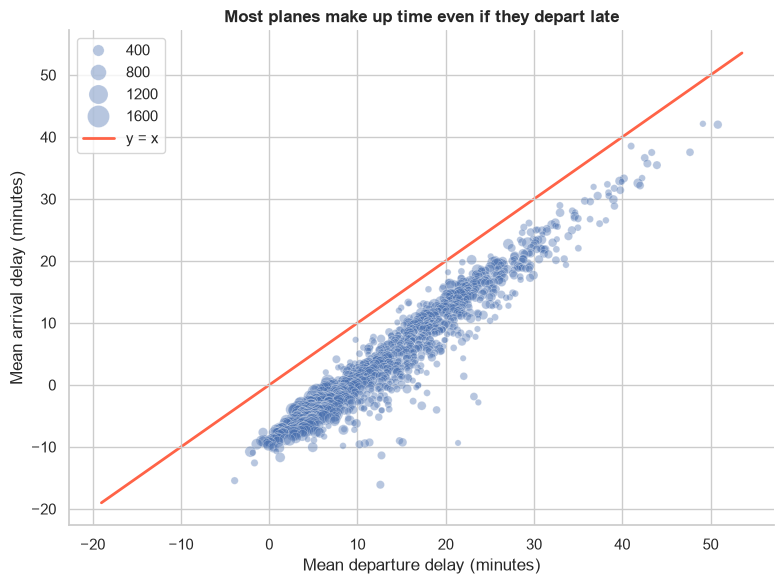

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=tailnum_delay, x='mean_dep_delay', y='mean_arr_delay',
    size='n', sizes=(20, 300), alpha=0.4, ax=ax
)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, color='tomato', linewidth=2, zorder=0, label='y = x')

ax.set_title('Most planes make up time even if they depart late', fontweight='bold')
ax.set_xlabel('Mean departure delay (minutes)')
ax.set_ylabel('Mean arrival delay (minutes)')
ax.legend(title='')
sns.despine()
plt.tight_layout()
plt.show()

## 10. Joins

A **join** stitches tables together on a shared column. We match each flight to its aircraft using `tailnum`, so we can see the plane's build year and model alongside the flight. A `LEFT JOIN` keeps every flight even when the plane is missing from the `planes` table, filling the gaps with nulls.

In [48]:
start = time.perf_counter()
joined = con.sql("""
    SELECT
        f.year, f.month, f.day, f.carrier, f.flight, f.tailnum,
        p.year AS year_built, p.manufacturer, p.model
    FROM flights AS f
    LEFT JOIN planes AS p ON f.tailnum = p.tailnum
    LIMIT 10
""").df()
print(f'SQL: {time.perf_counter() - start:.3f}s')
joined

SQL: 0.006s


,year,month,day,carrier,flight,tailnum,year_built,manufacturer,model
0,2023,4,11,DL,315,N929DZ,2019.0,BOEING,737-900ER
1,2023,4,11,B6,439,N355JB,2013.0,EMBRAER,ERJ 190-100 IGW
2,2023,4,11,9E,1393,N909XJ,2007.0,BOMBARDIER INC,CL-600-2D24
3,2023,4,11,DL,140,N344DN,2018.0,AIRBUS,A321-211
4,2023,4,11,DL,607,N135DQ,2020.0,AIRBUS CANADA LTD PTNRSP,BD-500-1A10
5,2023,4,11,B6,756,N559JB,2003.0,AIRBUS,A320-232
6,2023,4,11,AA,142,N335SN,2021.0,BOEING,737-8
7,2023,4,11,YX,1575,N233JQ,2008.0,EMBRAER-EMPRESA BRASILEIRA DE,ERJ 170-200 LR
8,2023,4,11,AA,557,N163US,2001.0,AIRBUS INDUSTRIE,A321-211
9,2023,4,11,DL,828,N133DU,2020.0,AIRBUS CANADA LTD PTNRSP,BD-500-1A10


The pandas equivalent is `merge`:

In [19]:
start = time.perf_counter()
joined_pd = (
    flights
    .merge(
        planes.rename(columns={'year': 'year_built'})
              [['tailnum','year_built','manufacturer','model']],
        on='tailnum', how='left'
    )
    [['year','month','day','carrier','flight','tailnum','year_built','manufacturer','model']]
)
print(f'pandas: {time.perf_counter() - start:.3f}s')
joined_pd.head(10)

pandas: 0.093s


,year,month,day,carrier,flight,tailnum,year_built,manufacturer,model
0,2023,1,1,UA,628,N25201,1999.0,BOEING,737-824
1,2023,1,1,DL,393,N830DN,2014.0,BOEING,737-932ER
2,2023,1,1,B6,371,N807JB,2012.0,AIRBUS,A320-232
3,2023,1,1,B6,1053,N265JB,2006.0,EMBRAER,ERJ 190-100 IGW
4,2023,1,1,UA,219,N17730,1999.0,BOEING,737-724
5,2023,1,1,AA,499,N925AN,1999.0,BOEING,737-823
6,2023,1,1,B6,996,N2043J,2020.0,AIRBUS,A321-271NX
7,2023,1,1,AA,981,N918AN,1999.0,BOEING,737-823
8,2023,1,1,UA,206,N13113,1995.0,BOEING,757-224
9,2023,1,1,NK,225,N912NK,2018.0,AIRBUS,A320-271N


## What happens if you forget `ORDER_BY` 

Interestingly, the two tables (pandas and SQL)  may not always be the same! If tou dont believe me, reurn the SQL join.
Is something wrong with either? The two tables show different rows because neither query says what order it wants, and "the first 10" means different things to the two engines. -->

pandas `merge()` keeps the left frame's row order, so head(10) hands you the first ten rows of flights as they sit in the CSV, which is month 1, day 1, the top of the file.

DuckDB treats a table as an unordered set. Its `LEFT JOIN` builds a hash table on planes and probes it, and LIMIT 10 just grabs the first ten rows that fall out of that process. That order reflects how the join executed, not the original file order, which is why you land on month 7, day 21. Run it again on a different machine or after a version bump and the ten could change again.

So the values are all correct. Without an `ORDER BY`, the row order is simply not defined, and the two tools resolve that freedom differently.

> A SQL result is an unordered set and you must ask for an order if you want one. It is exactly the kind of thing that may come back to bite you later.

## 11. Readable SQL, and reading the plan

Long SQL gets hard to follow. A **CTE** (Common Table Expression), the `WITH` block, names an intermediate result so the query reads top to bottom, the same way pandas method chaining does. Here is the plane-delay question again, written as a CTE.

In [20]:
start = time.perf_counter()
cte = con.sql("""
    WITH per_plane AS (
        SELECT tailnum,
               ROUND(AVG(arr_delay), 2) AS mean_arr_delay,
               COUNT(*) AS n
        FROM flights
        GROUP BY tailnum
    )
    SELECT *
    FROM per_plane
    WHERE n > 100
    ORDER BY mean_arr_delay DESC
    LIMIT 10
""").df()
print(f'SQL: {time.perf_counter() - start:.3f}s')
cte

SQL: 0.006s


,tailnum,mean_arr_delay,n
0,N2017J,42.13,114
1,N2016J,41.99,218
2,N241SY,38.53,143
3,N974JT,37.54,181
4,N954JB,37.50,149
5,N2059J,36.64,181
6,N998JE,35.72,200
7,N913JB,35.46,200
8,N2086J,33.37,124
9,N971JT,33.31,202


The same in pandas. The method chain already reads in the CTE's order, so there is nothing new to learn here.

In [21]:
start = time.perf_counter()
cte_pd = (
    flights
    .groupby('tailnum', as_index=False)
    .agg(mean_arr_delay=('arr_delay','mean'), n=('flight','count'))
    .query('n > 100')
    .round(2)
    .sort_values('mean_arr_delay', ascending=False)
    .reset_index(drop=True)
)
print(f'pandas: {time.perf_counter() - start:.3f}s')
cte_pd.head(10)

pandas: 0.023s


,tailnum,mean_arr_delay,n
0,N2017J,42.13,114
1,N2016J,41.99,218
2,N241SY,38.53,143
3,N974JT,37.54,181
4,N954JB,37.50,149
5,N2059J,36.64,181
6,N998JE,35.72,200
7,N913JB,35.46,200
8,N2086J,33.37,124
9,N971JT,33.31,202


When a query is slow, `EXPLAIN` shows the plan the engine will run, and `EXPLAIN ANALYZE` runs it and reports where the time went. This turns "it feels slow" into something you can actually see.

In [22]:
print(con.sql("EXPLAIN SELECT dest, count(*) FROM flights GROUP BY dest").fetchall()[0][1])

┌───────────────────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_decompress_strin│
│           g(#0)           │
│             #1            │
│                           │
│         ~106 rows         │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│       HASH_GROUP_BY       │
│    ────────────────────   │
│         Groups: #0        │
│                           │
│        Aggregates:        │
│        count_star()       │
│                           │
│         ~106 rows         │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│            dest           │
│                           │
│       ~435,352 rows       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_compress_string_│
│        uinteger(#0)       │
│                           │
│       ~435,352 rows       │
└─────────

One SQL habit worth naming: SQL is **written** in one order but **executed** in another.

```
Written:   SELECT -> FROM -> WHERE -> GROUP BY -> HAVING -> ORDER BY -> LIMIT
Executed:  FROM -> WHERE -> GROUP BY -> HAVING -> SELECT -> ORDER BY -> LIMIT
```

This is why you can filter on a column in `WHERE` that you never select, and why an alias made in `SELECT` is not available in `WHERE`. pandas chaining follows the executed order, which is part of why it feels intuitive.

## 12. DuckDB reads files directly

You do not have to load a file into pandas before querying it. DuckDB reads CSV and Parquet itself, which matters when the file is bigger than memory. Here we write a small CSV, then query it with `read_csv_auto` without ever creating a DataFrame.

In [23]:
airlines.to_csv('airlines_local.csv', index=False)

start = time.perf_counter()
from_file = con.sql("SELECT * FROM read_csv_auto('airlines_local.csv') LIMIT 5").df()
print(f'DuckDB read_csv_auto: {time.perf_counter() - start:.3f}s')
from_file

DuckDB read_csv_auto: 0.004s


,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.


The pandas equivalent loads the whole file into memory first, then slices:

In [24]:
start = time.perf_counter()
from_file_pd = pd.read_csv('airlines_local.csv').head(5)
print(f'pandas read_csv: {time.perf_counter() - start:.3f}s')
from_file_pd

pandas read_csv: 0.001s


,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.


Two more everyday tools. `SUMMARIZE` gives instant column statistics, and `COPY ... TO` writes a query result straight to a file.

In [25]:
start = time.perf_counter()
summary = con.sql("SUMMARIZE SELECT dep_delay, arr_delay, distance FROM flights").df()
print(f'DuckDB SUMMARIZE: {time.perf_counter() - start:.3f}s')
summary

DuckDB SUMMARIZE: 0.061s


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,dep_delay,DOUBLE,-50.0,1813.0,933,13.837372295779225,54.313851505195906,-6.0,-2.4992982289489123,9.72694452409535,435352,2.47
1,arr_delay,DOUBLE,-97.0,1812.0,1065,4.344803201377425,57.8688934455226,-21.615984478841987,-9.852525438757432,9.064383893481402,435352,2.88
2,distance,BIGINT,80,4983,313,977.5029814954336,702.8575138671115,470,763,1182,435352,0.00


The pandas equivalent is `describe`:

In [26]:
start = time.perf_counter()
summary_pd = flights[['dep_delay','arr_delay','distance']].describe()
print(f'pandas describe: {time.perf_counter() - start:.3f}s')
summary_pd

pandas describe: 0.028s


,dep_delay,arr_delay,distance
count,424614.000000,422818.000000,435352.000000
mean,13.837372,4.344803,977.502981
std,54.313852,57.868893,702.857514
min,-50.000000,-97.000000,80.000000
25%,-6.000000,-22.000000,479.000000
50%,-2.000000,-10.000000,762.000000
75%,10.000000,9.000000,1182.000000
max,1813.000000,1812.000000,4983.000000


In [27]:
start = time.perf_counter()
con.execute("""
    COPY (
        SELECT carrier, ROUND(AVG(arr_delay), 2) AS mean_arr_delay, COUNT(*) AS n
        FROM flights GROUP BY carrier ORDER BY mean_arr_delay DESC
    ) TO 'carrier_delays.parquet' (FORMAT parquet)
""")
print(f'DuckDB COPY: {time.perf_counter() - start:.3f}s')
print('Wrote carrier_delays.parquet:', os.path.getsize('carrier_delays.parquet'), 'bytes')

DuckDB COPY: 0.004s
Wrote carrier_delays.parquet: 696 bytes


In pandas you compute the result first, then write it out:

In [28]:
start = time.perf_counter()
(
    flights
    .groupby('carrier', as_index=False)
    .agg(mean_arr_delay=('arr_delay','mean'), n=('flight','count'))
    .round(2)
    .sort_values('mean_arr_delay', ascending=False)
    .to_parquet('carrier_delays_pd.parquet')
)
print(f'pandas to_parquet: {time.perf_counter() - start:.3f}s')
print('Wrote carrier_delays_pd.parquet:', os.path.getsize('carrier_delays_pd.parquet'), 'bytes')

pandas to_parquet: 0.059s
Wrote carrier_delays_pd.parquet: 3526 bytes


### In-memory versus on disk

Everything so far lived in RAM and vanishes when the kernel restarts. To keep a database between sessions, connect to a file instead of `:memory:`.

```python
disk_con = duckdb.connect('flights.duckdb')   # persists to a file on disk
```


---
# Apache Arrow: data that does not fit in memory

Everything above fit comfortably in RAM. Now the data will not.

**Apache Arrow** is a shared in-memory format for tabular data. Its trick is that different tools can pass data to each other without copying or converting it, because they agree on the exact memory layout. Arrow can also point at a folder of files on disk and treat them as one dataset, reading only the pieces a query needs. That is what lets us work with data far larger than memory.

We use the NYC taxi trip records, which the city publishes as Parquet, running to hundreds of millions of rows.

## 13. Opening a large dataset

Point Arrow at a folder of Parquet files and it reads only the metadata, building a dataset object almost instantly. It does **not** load the rows.

The full TLC archive is roughly 37 GB and around 1.7 billion rows. If you have downloaded it, set `NYC_TAXI_PATH` to that folder. If not, the notebook falls back to a single month streamed straight from the city's servers, so every cell below still runs.

Full data: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [29]:
NYC_TAXI_PATH = '/path/to/nyc-taxi'   # <-- set this to your local hive-partitioned folder

HAVE_FULL = os.path.isdir(NYC_TAXI_PATH)

if HAVE_FULL:
    start = time.time()
    nyc_taxi = ds.dataset(NYC_TAXI_PATH, format='parquet', partitioning='hive')
    print(f'Opened full dataset in {time.time() - start:.2f}s')
    print(f'Rows: {nyc_taxi.count_rows():,}')      # reads file footers only, still fast
    print(f'Columns: {len(nyc_taxi.schema)}')
else:
    print('Full dataset not found. Using a single-month fallback over the network.')
    print('DuckDB will read one Parquet file directly from the TLC servers.')

Full dataset not found. Using a single-month fallback over the network.
DuckDB will read one Parquet file directly from the TLC servers.


Whether or not you have the full archive, DuckDB can query the Parquet files directly with `read_parquet`. The line below reads one month straight from the city's servers. The `httpfs` extension that enables reading over HTTPS installs itself on first use.

In [30]:
# One public month, read straight off the web.
TAXI_URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-05.parquet'

con.execute('INSTALL httpfs; LOAD httpfs;')

start = time.perf_counter()
preview = con.sql(f"""
    SELECT passenger_count, trip_distance, total_amount, tip_amount
    FROM read_parquet('{TAXI_URL}')
    LIMIT 10
""").df()
print(f'DuckDB read_parquet: {time.perf_counter() - start:.3f}s')
preview

DuckDB read_parquet: 0.401s


,passenger_count,trip_distance,total_amount,tip_amount
0,1,7.51,45.40,0.00
1,1,6.14,49.81,9.56
2,1,2.40,28.58,3.73
3,0,1.20,18.05,3.00
4,2,0.86,14.64,2.44
5,1,5.89,40.68,6.78
6,1,1.60,17.15,2.85
7,1,3.84,26.55,1.00
8,1,0.61,15.01,3.46
9,1,1.98,21.44,4.29


The pandas equivalent has to download and load the whole file before it can show ten rows:

In [31]:
start = time.perf_counter()
preview_pd = pd.read_parquet(
    TAXI_URL, columns=['passenger_count','trip_distance','total_amount','tip_amount']
).head(10)
print(f'pandas read_parquet: {time.perf_counter() - start:.3f}s')
preview_pd

pandas read_parquet: 0.736s


,passenger_count,trip_distance,total_amount,tip_amount
0,1.0,7.51,45.40,0.00
1,1.0,6.14,49.81,9.56
2,1.0,2.40,28.58,3.73
3,0.0,1.20,18.05,3.00
4,2.0,0.86,14.64,2.44
5,1.0,5.89,40.68,6.78
6,1.0,1.60,17.15,2.85
7,1.0,3.84,26.55,1.00
8,1.0,0.61,15.01,3.46
9,1.0,1.98,21.44,4.29


## 14. The headline: push the work down

Here is the lesson worth the whole session. We want, per year, the share of trips that carried more than one passenger.

The tempting way is to pull the columns into pandas and aggregate there. The problem is `.to_pandas()`: it drags every filtered row into memory before any grouping happens. On the full dataset this is slow and can exhaust memory.

The fix is to hand the Arrow dataset to DuckDB with `duckdb.arrow()`, a **zero-copy** handoff, and let DuckDB do the grouping before anything comes back. Only the tiny summary lands in pandas.

Run both on the full dataset to feel the difference. The comparison below runs whichever source you have.

In [32]:
# Slow path: filter, then pull everything to pandas to aggregate
start = time.time()

if HAVE_FULL:
    pct_pandas = (
        nyc_taxi
        .to_table(columns=['year', 'passenger_count'],
                  filter=ds.field('year') >= 2015)
        .to_pandas()
        .groupby('year', as_index=False)
        .agg(all_trips=('passenger_count', 'count'),
             shared_trips=('passenger_count', lambda x: (x > 1).sum()))
        .assign(pct_shared=lambda d: (d['shared_trips'] / d['all_trips'] * 100).round(2))
        .sort_values('year')
    )
else:
    pct_pandas = (
        pd.read_parquet(TAXI_URL, columns=['tpep_pickup_datetime', 'passenger_count'])
        .assign(year=lambda d: d['tpep_pickup_datetime'].dt.year)
        .groupby('year', as_index=False)
        .agg(all_trips=('passenger_count', 'count'),
             shared_trips=('passenger_count', lambda x: (x > 1).sum()))
        .assign(pct_shared=lambda d: (d['shared_trips'] / d['all_trips'] * 100).round(2))
        .sort_values('year')
    )

print(f'pandas: {time.time() - start:.2f}s')
pct_pandas

pandas: 0.86s


,year,all_trips,shared_trips,pct_shared
0,2008,1,0,0.00
1,2009,1,0,0.00
2,2026,3135463,544214,17.36


In [33]:
# Fast path: hand Arrow (or a Parquet file) to DuckDB, aggregate before collecting
start = time.time()

if HAVE_FULL:
    source = duckdb.arrow(nyc_taxi)   # zero-copy handoff
    pct_shared = source.query('t', """
        SELECT year,
               COUNT(*) AS all_trips,
               SUM(CASE WHEN passenger_count > 1 THEN 1 ELSE 0 END) AS shared_trips,
               ROUND(100.0 * SUM(CASE WHEN passenger_count > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_shared
        FROM t
        WHERE year >= 2015
        GROUP BY year
        ORDER BY year
    """).df()
else:
    pct_shared = con.sql(f"""
        SELECT EXTRACT(year FROM tpep_pickup_datetime) AS year,
               COUNT(*) AS all_trips,
               SUM(CASE WHEN passenger_count > 1 THEN 1 ELSE 0 END) AS shared_trips,
               ROUND(100.0 * SUM(CASE WHEN passenger_count > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_shared
        FROM read_parquet('{TAXI_URL}')
        GROUP BY year
        ORDER BY year
    """).df()

print(f'DuckDB (aggregate first): {time.time() - start:.2f}s')
pct_shared

DuckDB (aggregate first): 0.32s


,year,all_trips,shared_trips,pct_shared
0,2008,1,0.0,0.0
1,2009,1,0.0,0.0
2,2026,4090834,544214.0,13.3


The result is the same, but the DuckDB route stays small the whole way through. On the full archive the gap is roughly ten to one, and more importantly it runs on a laptop that could never hold the raw rows.

## 15. One more, with a chart: mean tip percentage by passenger count

Same idea, a richer query. We compute the mean tip as a share of the fare, for trips over ten dollars, grouped by passenger count.

In [34]:
start = time.time()
if HAVE_FULL:
    tip_by_passengers = duckdb.arrow(nyc_taxi).query('t', """
        SELECT passenger_count,
               ROUND(AVG(100.0 * tip_amount / total_amount), 2) AS mean_tip_pct,
               COUNT(*) AS n
        FROM t
        WHERE total_amount > 10
        GROUP BY passenger_count
        ORDER BY passenger_count
    """).df()
else:
    tip_by_passengers = con.sql(f"""
        SELECT passenger_count,
               ROUND(AVG(100.0 * tip_amount / total_amount), 2) AS mean_tip_pct,
               COUNT(*) AS n
        FROM read_parquet('{TAXI_URL}')
        WHERE total_amount > 10
        GROUP BY passenger_count
        ORDER BY passenger_count
    """).df()
print(f'DuckDB: {time.time() - start:.2f}s')
tip_by_passengers

DuckDB: 0.18s


,passenger_count,mean_tip_pct,n
0,0,12.52,12082
1,1,12.35,2526292
2,2,12.70,388525
3,3,12.25,82645
4,4,11.61,52074
5,5,13.11,7478
6,6,12.93,4483
7,8,16.67,1
8,<NA>,1.30,945046


The same in pandas, reading only the columns it needs, then aggregating in memory:

In [35]:
start = time.time()
if HAVE_FULL:
    tip_source = (
        nyc_taxi
        .to_table(columns=['passenger_count','tip_amount','total_amount'],
                  filter=ds.field('total_amount') > 10)
        .to_pandas()
    )
else:
    tip_source = pd.read_parquet(
        TAXI_URL, columns=['passenger_count','tip_amount','total_amount']
    ).query('total_amount > 10')

tip_by_passengers_pd = (
    tip_source
    .assign(tip_pct=lambda d: 100.0 * d['tip_amount'] / d['total_amount'])
    .groupby('passenger_count', as_index=False)
    .agg(mean_tip_pct=('tip_pct','mean'), n=('tip_pct','count'))
    .round({'mean_tip_pct': 2})
    .sort_values('passenger_count')
    .reset_index(drop=True)
)
print(f'pandas: {time.time() - start:.2f}s')
tip_by_passengers_pd

pandas: 0.89s


,passenger_count,mean_tip_pct,n
0,0.0,12.52,12082
1,1.0,12.35,2526292
2,2.0,12.70,388525
3,3.0,12.25,82645
4,4.0,11.61,52074
5,5.0,13.11,7478
6,6.0,12.93,4483
7,8.0,16.67,1


Real data is messy. You will see stray `passenger_count` values like 0 or absurdly large numbers, each backed by a handful of rows. That is a teaching moment in itself: always sanity-check the counts before trusting a headline. We keep the sensible range for the chart.

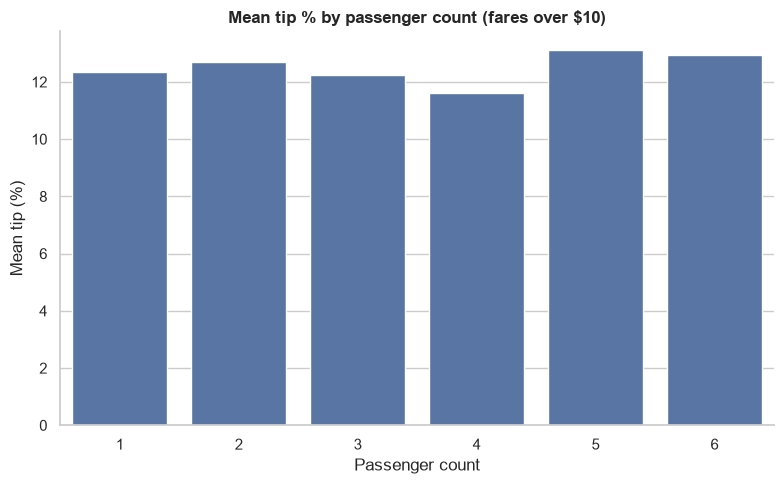

In [36]:
plot_data = (
    tip_by_passengers
    .dropna(subset=['passenger_count'])
    .query('passenger_count >= 1 and passenger_count <= 6')
    .assign(passenger_count=lambda d: d['passenger_count'].astype(int).astype(str))
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=plot_data, x='passenger_count', y='mean_tip_pct', ax=ax)
ax.set_title('Mean tip % by passenger count (fares over $10)', fontweight='bold')
ax.set_xlabel('Passenger count')
ax.set_ylabel('Mean tip (%)')
sns.despine()
plt.tight_layout()
plt.show()

## 16. Your turn

Two short exercises. Try each in SQL, then check yourself against the solution. Both run on whichever taxi source you have.

**Exercise 1.** Count the total number of rides for each month in the fallback file (or for 2019 in the full data).

**Exercise 2.** Find the longest single trip distance recorded in each month.

In [37]:
# Exercise 1 solution
start = time.time()
if HAVE_FULL:
    ex1 = duckdb.arrow(nyc_taxi).query('t', """
        SELECT month, COUNT(*) AS n
        FROM t WHERE year = 2019
        GROUP BY month ORDER BY month
    """).df()
else:
    ex1 = con.sql(f"""
        SELECT EXTRACT(month FROM tpep_pickup_datetime) AS month, COUNT(*) AS n
        FROM read_parquet('{TAXI_URL}')
        GROUP BY month ORDER BY month
    """).df()
print(f'DuckDB: {time.time() - start:.2f}s')
ex1

DuckDB: 0.11s


,month,n
0,1,1
1,4,11
2,5,4090822
3,6,1
4,12,1


Exercise 1 in pandas:

In [38]:
start = time.time()
if HAVE_FULL:
    ex1_pd = (
        nyc_taxi.to_table(columns=['year','month'], filter=ds.field('year') == 2019)
        .to_pandas().groupby('month', as_index=False).agg(n=('month','count'))
        .sort_values('month').reset_index(drop=True)
    )
else:
    ex1_pd = (
        pd.read_parquet(TAXI_URL, columns=['tpep_pickup_datetime'])
        .assign(month=lambda d: d['tpep_pickup_datetime'].dt.month)
        .groupby('month', as_index=False).agg(n=('month','count'))
        .sort_values('month').reset_index(drop=True)
    )
print(f'pandas: {time.time() - start:.2f}s')
ex1_pd

pandas: 0.75s


,month,n
0,1,1
1,4,11
2,5,4090822
3,6,1
4,12,1


In [39]:
# Exercise 2 solution
start = time.time()
if HAVE_FULL:
    ex2 = duckdb.arrow(nyc_taxi).query('t', """
        SELECT month, MAX(trip_distance) AS longest_trip
        FROM t WHERE year = 2019
        GROUP BY month ORDER BY month
    """).df()
else:
    ex2 = con.sql(f"""
        SELECT EXTRACT(month FROM tpep_pickup_datetime) AS month,
               MAX(trip_distance) AS longest_trip
        FROM read_parquet('{TAXI_URL}')
        GROUP BY month ORDER BY month
    """).df()
print(f'DuckDB: {time.time() - start:.2f}s')
ex2

DuckDB: 0.12s


,month,longest_trip
0,1,13.01
1,4,16.61
2,5,307491.47
3,6,11.11
4,12,2.28


Exercise 2 in pandas:

In [40]:
start = time.time()
if HAVE_FULL:
    ex2_pd = (
        nyc_taxi.to_table(columns=['year','month','trip_distance'], filter=ds.field('year') == 2019)
        .to_pandas().groupby('month', as_index=False).agg(longest_trip=('trip_distance','max'))
        .sort_values('month').reset_index(drop=True)
    )
else:
    ex2_pd = (
        pd.read_parquet(TAXI_URL, columns=['tpep_pickup_datetime','trip_distance'])
        .assign(month=lambda d: d['tpep_pickup_datetime'].dt.month)
        .groupby('month', as_index=False).agg(longest_trip=('trip_distance','max'))
        .sort_values('month').reset_index(drop=True)
    )
print(f'pandas: {time.time() - start:.2f}s')
ex2_pd

pandas: 0.87s


,month,longest_trip
0,1,13.01
1,4,16.61
2,5,307491.47
3,6,11.11
4,12,2.28


## 17. Which tool, when

No single tool wins everything. A rough guide:

- **pandas** when the data fits in memory and you want fast, interactive, exploratory work with the full Python ecosystem at hand.
- **DuckDB with SQL** when the work is heavy aggregation, joins across tables, or window functions, or when the data is on disk and you want to query it without loading it first.
- **Arrow with DuckDB** when the data does not fit in memory at all. Let Arrow scan the files and DuckDB do the aggregation, so only the summary ever reaches Python.

The three are not rivals. A common pattern is Arrow and DuckDB to shrink a huge dataset down to a small result, then pandas and seaborn to explore and plot it, exactly as we did here.

## Resources

- [SQL Murder Mystery](https://mystery.knightlab.com/) learn SQL by solving a crime
- [Select Star SQL](https://selectstarsql.com/) interactive SQL tutorial
- [A Beginner's Guide to the True Order of SQL Operations](https://blog.jooq.org/a-beginners-guide-to-the-true-order-of-sql-operations/)
- [Bigger data with Arrow and DuckDB](https://jthomasmock.github.io/bigger-data/)
- [Apache Arrow docs](https://arrow.apache.org/docs/python/)
- [DuckDB Python docs](https://duckdb.org/docs/api/python/overview)